<a href="https://colab.research.google.com/github/Cefcapacitar/Bienes-raices/blob/main/Segunda_parte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bienes raíces - Ejemplos en Python**
==
*Magister Jorge Córdoba*
===
### Cualquier duda sobre estos códigos o querés profundizar sobre los mismos, escribime por MD a **@cefcapacitar**

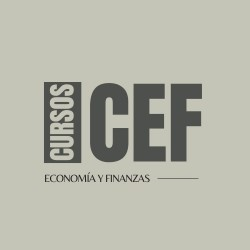

# 🏢 Segunda parte
## Cinco Ejemplos Automatizados de Valuación Inmobiliaria

---

Este notebook contiene **cinco situaciones reales automatizadas en Python** que cubren los siguientes temas:

| # | Ejemplo | Tema del módulo |
|---|---------|----------------|
| 1 | Valuación por comparables con factores de homogeneización | Tipos de valuación |
| 2 | Costo de Reposición Depreciado (CRD) con tabla Ross-Heidecke | Tipos de valuación |
| 3 | Análisis VAN y TIR para inversión en edificio de oficinas | Análisis financiero |
| 4 | WACC y evaluación de financiamiento mixto en proyecto residencial | Análisis financiero |
| 5 | Valuación de fondo de comercio por capitalización de ingresos | Valuaciones especiales |

---
> **Nota pedagógica:** Todos los datos son ficticios y construidos con fines educativos.

In [ ]:
# ============================================================
# INSTALACIÓN Y CARGA DE LIBRERÍAS
# ============================================================
!pip install matplotlib pandas numpy scipy tabulate --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import brentq
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

# Estilo general de gráficos
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Librerías cargadas correctamente.')

---
# 📌 EJEMPLO 1 — Valuación por Comparables con Factores de Homogeneización

## Situación
**Contexto:** La tasadora **Verónica Salguero** recibe el encargo de valuar un lote urbano ubicado en el barrio **Parque Atlántico** de la ciudad de **Rosario**. El propietario, **Rodrigo Castellanos**, necesita el dictamen para respaldar una operación de crédito hipotecario.

**Inmueble base:**
- Superficie: 350 m²
- Frente: 10 m / Fondo: 35 m
- Ubicación: media cuadra
- Servicios: todos (agua, gas, luz, cloacas, pavimento)
- Sin pendiente topográfica

**Objetivo:** Determinar el valor unitario (USD/m²) del lote aplicando factores de homogeneización sobre tres comparables relevados en la zona.

**Factores aplicados:** ubicación, frente, profundidad (regla 4-3-2-1), topografía y superficie.

In [ ]:
# ============================================================
# EJEMPLO 1: VALUACIÓN POR COMPARABLES
# ============================================================

print('=' * 65)
print('  EJEMPLO 1 — VALUACIÓN POR COMPARABLES')
print('  Tasadora: Verónica Salguero | Inmueble en Parque Atlántico, Rosario')
print('=' * 65)

# ------------------------------------------------------------------
# 1.1  DATOS DEL INMUEBLE BASE
# ------------------------------------------------------------------
base = {
    'frente': 10,        # metros
    'fondo': 35,         # metros
    'superficie': 350,   # m²
    'ubicacion': 'media_cuadra',
    'pendiente': 0.0,    # sin pendiente
    'servicios': 'completos'
}

# Frente tipo de la zona
frente_tipo = 10   # metros
# Fondo tipo de la zona
fondo_tipo  = 30   # metros

# ------------------------------------------------------------------
# 1.2  DATOS DE LOS COMPARABLES
# ------------------------------------------------------------------
comparables = pd.DataFrame({
    'Comparable': ['Comp-A', 'Comp-B', 'Comp-C'],
    'Precio_total_USD': [82_000, 105_000, 68_000],
    'Superficie_m2':    [420,    490,     320],
    'Frente_m':         [12,     10,      8],
    'Fondo_m':          [35,     49,      40],
    'Ubicacion':        ['esquina', 'media_cuadra', 'media_cuadra'],
    'Pendiente_pct':    [0.0,      5.0,             0.0],
    'Servicios':        ['completos', 'completos', 'sin_gas'],
    'Recencia_meses':   [2, 5, 8],
})

comparables['Precio_unit_USD_m2'] = (comparables['Precio_total_USD']
                                      / comparables['Superficie_m2']).round(2)

print('\n📋 Comparables relevados:')
print(tabulate(comparables[['Comparable','Precio_unit_USD_m2','Frente_m',
                              'Fondo_m','Ubicacion','Pendiente_pct',
                              'Servicios','Recencia_meses']],
               headers='keys', tablefmt='rounded_outline', showindex=False))

# ------------------------------------------------------------------
# 1.3  FACTORES DE HOMOGENEIZACIÓN
# ------------------------------------------------------------------

# A) Factor de ubicación
k_ubic = {'esquina': 0.90, 'media_cuadra': 1.00, 'corredor_comercial': 0.88}
# (se divide porque ajustamos el comparable hacia el lote base)

# B) Factor de frente  → raíz cuadrada del cociente frente_tipo / frente_comp
def factor_frente(frente_comp, frente_tipo):
    return np.sqrt(frente_tipo / frente_comp)

# C) Factor de profundidad — Regla 4-3-2-1
# Divide el lote en 4 franjas iguales y asigna 40%-30%-20%-10% del valor.
# Calcula qué proporción del valor corresponde a la profundidad real vs. tipo.
def valor_relativo_profundidad(fondo, fondo_tipo):
    """Fracción de valor que tiene un lote de 'fondo' metros respecto al fondo_tipo."""
    pesos = [0.40, 0.30, 0.20, 0.10]  # regla 4-3-2-1
    def acum(f):
        franja = f / 4
        total = 0
        for i, p in enumerate(pesos):
            limite_superior = franja * (i + 1)
            limite_inferior = franja * i
            total += p * min(f, limite_superior) / franja if f > limite_inferior else 0
        return total / f  # valor por metro

    vr_comp = acum(fondo)
    vr_tipo = acum(fondo_tipo)
    return vr_tipo / vr_comp  # factor que lleva el comparable al tipo

# D) Factor topográfico
def factor_topografico(pendiente_pct):
    """Penalización por pendiente: -2 % del valor por cada 5 % de desnivel."""
    return 1 - (pendiente_pct / 5) * 0.02

# E) Factor de servicios
k_serv = {'completos': 1.00, 'sin_gas': 1.04, 'sin_cloacas': 1.08}

# ------------------------------------------------------------------
# 1.4  APLICACIÓN DE FACTORES
# ------------------------------------------------------------------
resultados = []
for _, row in comparables.iterrows():
    pu = row['Precio_unit_USD_m2']

    fu = k_ubic[row['Ubicacion']]
    ff = factor_frente(row['Frente_m'], frente_tipo)
    fp = valor_relativo_profundidad(row['Fondo_m'], fondo_tipo)
    ft = factor_topografico(row['Pendiente_pct'])
    fs = k_serv[row['Servicios']]

    factor_total = fu * ff * fp * ft * fs
    pu_ajustado = round(pu * factor_total, 2)

    resultados.append({
        'Comparable': row['Comparable'],
        'P.U. original': pu,
        'F. Ubicación': round(fu, 4),
        'F. Frente': round(ff, 4),
        'F. Profundidad': round(fp, 4),
        'F. Topografía': round(ft, 4),
        'F. Servicios': round(fs, 4),
        'Factor Total': round(factor_total, 4),
        'P.U. Ajustado': pu_ajustado,
        'Recencia_meses': row['Recencia_meses']
    })

df_res = pd.DataFrame(resultados)

print('\n🔧 Factores de homogeneización aplicados:')
print(tabulate(df_res.drop(columns='Recencia_meses'),
               headers='keys', tablefmt='rounded_outline',
               showindex=False, floatfmt='.4f'))

# ------------------------------------------------------------------
# 1.5  PONDERACIÓN FINAL (inverso de la recencia)
# ------------------------------------------------------------------
pesos_pond = 1 / df_res['Recencia_meses']
pesos_pond /= pesos_pond.sum()

valor_unitario_final = (df_res['P.U. Ajustado'] * pesos_pond).sum()
valor_total_lote     = valor_unitario_final * base['superficie']

print(f'\n📊 Ponderación por recencia:')
for i, (_, r) in enumerate(df_res.iterrows()):
    print(f"   {r['Comparable']}: peso = {pesos_pond.iloc[i]:.4f}  |  "
          f"P.U. ajustado = USD {r['P.U. Ajustado']:.2f}/m²")

print(f'\n✅ VALOR UNITARIO FINAL: USD {valor_unitario_final:.2f} / m²')
print(f'✅ VALOR TOTAL DEL LOTE ({base["superficie"]} m²): USD {valor_total_lote:,.2f}')

In [ ]:
import numpy as np
# ------------------------------------------------------------------
# GRÁFICO EJEMPLO 1
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ejemplo 1 — Valuación por Comparables\nParque Atlántico, Rosario',
             fontweight='bold', fontsize=13)

comps   = df_res['Comparable'].tolist() + ['BASE (resultado)']
pu_orig = df_res['P.U. original'].tolist() + [np.nan]
pu_ajus = df_res['P.U. Ajustado'].tolist() + [valor_unitario_final]

x = np.arange(len(comps))
w = 0.35

bars1 = axes[0].bar(x - w/2, pu_orig, w, label='P.U. original',
                    color='#7bafd4', edgecolor='white')
bars2 = axes[0].bar(x + w/2, pu_ajus, w, label='P.U. ajustado',
                    color='#2c6e49', edgecolor='white')

axes[0].set_title('Precio unitario: original vs. ajustado (USD/m²)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comps)
axes[0].set_ylabel('USD / m²')
axes[0].legend()
axes[0].bar_label(bars1, fmt='%.1f', padding=3, fontsize=9)
axes[0].bar_label(bars2, fmt='%.1f', padding=3, fontsize=9)
axes[0].set_ylim(0, max(pu_orig[:-1] + pu_ajus) * 1.18)

# Factores totales
axes[1].bar(df_res['Comparable'], df_res['Factor Total'],
            color=['#e07b39','#7bafd4','#c44b4b'], edgecolor='white', width=0.4)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1, label='Factor neutro = 1')
axes[1].set_title('Factor de homogeneización total por comparable')
axes[1].set_ylabel('Factor total')
axes[1].legend()
for i, v in enumerate(df_res['Factor Total']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---
# 📌 EJEMPLO 2 — Costo de Reposición Depreciado (CRD) con Tabla Ross-Heidecke

## Situación
**Contexto:** El tasador **Marcelo Figueroa** debe valuar una vivienda ubicada en **San Rafael, Mendoza**, propiedad de **Beatriz Quintero**. El inmueble tiene **58 años de antigüedad** y recibió una **remodelación importante (35%)** hace 12 años. Se solicita el informe para un proceso sucesorio.

**Datos constructivos:**
- Superficie cubierta: 148 m²
- Tipología: vivienda medio-alto estándar
- Estado de conservación: **regular** (según Ross-Heidecke)
- Vida útil original estimada: 80 años
- Vida útil de la remodelación: 40 años
- Valor residual estimado: 3 % del CRB

**Objetivo:** Calcular el CRB, aplicar la fórmula de vida útil remanente efectiva, determinar el coeficiente K de Ross-Heidecke y obtener el CRD.

In [ ]:
# ============================================================
# EJEMPLO 2: COSTO DE REPOSICIÓN DEPRECIADO (CRD) — ROSS-HEIDECKE
# ============================================================

print('=' * 65)
print('  EJEMPLO 2 — COSTO DE REPOSICIÓN DEPRECIADO (CRD)')
print('  Tasador: Marcelo Figueroa | Vivienda en San Rafael, Mendoza')
print('=' * 65)

# ------------------------------------------------------------------
# 2.1  DATOS DEL INMUEBLE
# ------------------------------------------------------------------
sup_cubierta   = 148      # m²
antig_original = 58       # años desde construcción original
vida_util_orig = 80       # años (vida útil total de la construcción original)
antig_remod    = 12       # años de la remodelación
vida_util_remd = 40       # años (vida útil total de la remodelación)
pct_remod      = 0.35     # 35 % de la edificación fue remodelada
valor_residual_pct = 0.03 # 3 % del CRB

# Estado de conservación (escala Ross-Heidecke)
# 1=Nuevo, 2=Muy bueno, 3=Bueno, 4=Regular, 5=Precario, 6=Malo, 7=Muy malo
estado = 'regular'  # estado 4

# ------------------------------------------------------------------
# 2.2  COSTO DE REPOSICIÓN BRUTO (CRB)
# Ecuación del módulo: y = 5.8134x + 623.59 (vivienda medio-alto)
# x = número de semestres desde referencia base (usamos semestre 8 ≈ 4 años)
# ------------------------------------------------------------------
semestre_ref   = 8
costo_x_m2_usd = round(5.8134 * semestre_ref + 623.59, 2)

# Rubros del presupuesto tipo (% sobre costo total)
rubros = {
    'Estructura y cimientos':        18.5,
    'Mampostería y revoques':        16.0,
    'Carpintería (puertas/ventanas)': 9.5,
    'Pisos y revestimientos':         8.0,
    'Aluminio y vidrios':             8.0,
    'Instalación eléctrica':          7.5,
    'Instalación sanitaria':          7.0,
    'Pintura y terminaciones':        6.5,
    'Techos e impermeabilizaciones':  6.0,
    'Gastos generales y honorarios': 13.0,
}

# CRB total
crb = round(costo_x_m2_usd * sup_cubierta, 2)
vr  = round(crb * valor_residual_pct, 2)

print(f'\n🏗️  Costo unitario estimado (ecuación):  USD {costo_x_m2_usd:.2f} / m²')
print(f'🏗️  CRB total ({sup_cubierta} m²):            USD {crb:,.2f}')
print(f'🏗️  Valor residual (3%):                 USD {vr:,.2f}')

# Tabla de rubros
df_rubros = pd.DataFrame({
    'Rubro': list(rubros.keys()),
    '% del total': list(rubros.values()),
    'Monto USD': [round(crb * p / 100, 2) for p in rubros.values()]
})
print('\n📋 Presupuesto tipo desagregado:')
print(tabulate(df_rubros, headers='keys', tablefmt='rounded_outline',
               showindex=False, floatfmt='.2f'))

# ------------------------------------------------------------------
# 2.3  VIDA ÚTIL REMANENTE EFECTIVA
# Fórmula: Vue = Vuo*(1-R) + VUr*R
# ------------------------------------------------------------------
vuo = max(vida_util_orig - antig_original, 0)   # vida útil remanente original
vur = max(vida_util_remd - antig_remod, 0)       # vida útil remanente de la remodelación
vue = round(vuo * (1 - pct_remod) + vur * pct_remod, 2)

# Vida útil total efectiva para calcular el porcentaje de vida transcurrida
# Se reconstruye: VU_efectiva = antigüedad_ponderada + Vue
# Antigüedad ponderada = antig_original*(1-R) + antig_remod*R
antig_pond = round(antig_original * (1 - pct_remod) + antig_remod * pct_remod, 2)
vu_total_efectiva = antig_pond + vue
pct_vida_transcurrida = round((antig_pond / vu_total_efectiva) * 100, 2)

print(f'\n⏳ Vida útil remanente original (Vuo):        {vuo} años')
print(f'⏳ Vida útil remanente remodelación (Vur):     {vur} años')
print(f'⏳ Vida útil remanente EFECTIVA (Vue):         {vue} años')
print(f'⏳ Antigüedad ponderada:                       {antig_pond} años')
print(f'⏳ % de vida transcurrida:                     {pct_vida_transcurrida} %')

# ------------------------------------------------------------------
# 2.4  TABLA ROSS-HEIDECKE — Coeficiente K
# Tabla simplificada: filas = % vida transcurrida, columnas = estado
# ------------------------------------------------------------------
estados_rh = ['nuevo', 'muy_bueno', 'bueno', 'regular', 'precario', 'malo', 'muy_malo']
# Porcentajes de depreciación (K*100) según tabla Ross-Heidecke estándar
tabla_rh = {
    10:  [0.32, 1.39, 2.72, 4.40, 7.05,  12.00, 20.00],
    20:  [0.63, 2.72, 5.25, 8.35, 13.00, 21.00, 34.00],
    30:  [0.99, 4.24, 8.07, 12.80, 19.50, 31.00, 48.00],
    40:  [1.42, 6.03, 11.40, 17.90, 27.00, 42.00, 62.00],
    50:  [1.98, 8.33, 15.60, 24.40, 36.30, 55.00, 75.00],
    60:  [2.72, 11.40, 21.20, 32.80, 48.00, 70.00, 87.00],
    70:  [3.84, 15.70, 28.80, 44.20, 62.00, 83.00, 95.00],
    80:  [5.80, 22.50, 40.50, 60.80, 78.00, 92.00, 98.00],
    90:  [10.10, 36.00, 60.00, 80.00, 92.00, 97.00, 99.50],
    100: [20.00, 60.00, 80.00, 93.00, 98.00, 99.50, 100.00],
}
df_rh = pd.DataFrame(tabla_rh, index=estados_rh).T
df_rh.index.name = '% Vida transcurrida'

# Interpolar coeficiente K para el % de vida transcurrida del inmueble
idx_estado = estados_rh.index(estado)   # índice de columna
xp = sorted(tabla_rh.keys())
yp = [tabla_rh[k][idx_estado] for k in xp]
k_pct = np.interp(pct_vida_transcurrida, xp, yp)
K = round(k_pct / 100, 6)

print(f'\n📐 Estado de conservación: {estado.upper()}')
print(f'📐 Coeficiente K (Ross-Heidecke): {K:.6f}  →  depreciación = {k_pct:.2f}%')

# ------------------------------------------------------------------
# 2.5  CRD = CRB - (CRB - Vr) * K
# ------------------------------------------------------------------
depreciacion = round((crb - vr) * K, 2)
crd = round(crb - depreciacion, 2)
crd_x_m2 = round(crd / sup_cubierta, 2)

print(f'\n💰 Depreciación total:          USD {depreciacion:,.2f}')
print(f'✅ CRD (Costo Reposición Dep.): USD {crd:,.2f}')
print(f'✅ CRD por m²:                  USD {crd_x_m2:.2f} / m²')

In [ ]:
# ------------------------------------------------------------------
# GRÁFICO EJEMPLO 2
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ejemplo 2 — Costo de Reposición Depreciado\nVivienda en San Rafael, Mendoza',
             fontweight='bold', fontsize=13)

# Gráfico A: Composición CRB / Depreciación / CRD
etiquetas = ['CRB', 'Depreciación', 'CRD']
valores   = [crb, depreciacion, crd]
colores   = ['#4a7fc1', '#d94e4e', '#2c6e49']
bars = axes[0].bar(etiquetas, valores, color=colores, edgecolor='white', width=0.4)
axes[0].set_title('Composición del valor (USD)')
axes[0].set_ylabel('USD')
for b, v in zip(bars, valores):
    axes[0].text(b.get_x() + b.get_width()/2, v + 500,
                 f'USD {v:,.0f}', ha='center', fontsize=10, fontweight='bold')

# Gráfico B: Curvas Ross-Heidecke por estado
pct_range = np.linspace(10, 100, 100)
colores_rh = ['#43aa8b','#90be6d','#f9c74f','#f8961e','#f3722c','#d62828','#6d0000']
for i, est in enumerate(estados_rh):
    yp_e = [tabla_rh[k][i] for k in xp]
    yvals = np.interp(pct_range, xp, yp_e)
    axes[1].plot(pct_range, yvals, label=est.replace('_',' ').title(),
                 color=colores_rh[i], linewidth=1.6)

# Marcar posición del inmueble
axes[1].scatter([pct_vida_transcurrida], [k_pct], s=120, color='black',
                zorder=5, label=f'Este inmueble\n({pct_vida_transcurrida}% — K={k_pct:.1f}%)')
axes[1].axvline(pct_vida_transcurrida, color='gray', linestyle=':', linewidth=1)
axes[1].axhline(k_pct, color='gray', linestyle=':', linewidth=1)
axes[1].set_title('Tabla Ross-Heidecke — Depreciación por estado')
axes[1].set_xlabel('% de vida transcurrida')
axes[1].set_ylabel('Coeficiente K (%)')
axes[1].legend(fontsize=7.5, loc='upper left')

plt.tight_layout()
plt.show()

---
# 📌 EJEMPLO 3 — Análisis VAN y TIR para Inversión en Edificio de Oficinas

## Situación
**Contexto:** La empresa **Andina Patrimonial S.A.** evalúa adquirir un edificio de oficinas en el microcentro de **Tucumán** por **USD 1.200.000**. El director de inversiones, **Nicolás Bravo**, debe presentar un análisis financiero al directorio.

**Flujos proyectados (10 años):**
- Ingresos por alquiler crecientes
- Gastos operativos anuales
- Inversión de mantenimiento en año 5
- Valor residual de reventa en año 10

**Objetivo:** Calcular el VAN con distintas tasas de descuento, determinar la TIR, y visualizar la curva VAN vs. tasa para identificar el punto de indiferencia.

In [ ]:
# ============================================================
# EJEMPLO 3: VAN Y TIR — EDIFICIO DE OFICINAS EN TUCUMÁN
# ============================================================

print('=' * 65)
print('  EJEMPLO 3 — ANÁLISIS VAN Y TIR')
print('  Empresa: Andina Patrimonial S.A. | Edificio en Tucumán')
print('=' * 65)

# ------------------------------------------------------------------
# 3.1  INVERSIÓN INICIAL Y FLUJOS
# ------------------------------------------------------------------
inversion_inicial = -1_200_000   # USD

# Ingresos por alquiler: crecen 4 % anual desde USD 96.000 en año 1
tasa_crecimiento_alquiler = 0.04
alquiler_año1 = 96_000

ingresos = [round(alquiler_año1 * (1 + tasa_crecimiento_alquiler)**(t-1), 2)
            for t in range(1, 11)]

# Gastos operativos: 28 % de los ingresos
gastos = [round(ing * 0.28, 2) for ing in ingresos]

# Inversión de mantenimiento en año 5
mantenimiento = [0]*10
mantenimiento[4] = -45_000

# Valor residual en año 10 (precio de reventa estimado)
valor_residual_fin = 1_400_000

# Flujos netos por período
flujos_netos = []
for i in range(10):
    fn = ingresos[i] - gastos[i] + mantenimiento[i]
    if i == 9:
        fn += valor_residual_fin
    flujos_netos.append(round(fn, 2))

# Flujo completo incluyendo inversión en t=0
flujos_completos = [inversion_inicial] + flujos_netos

# Tabla de flujos
df_flujos = pd.DataFrame({
    'Período': list(range(0, 11)),
    'Ingresos USD': [0] + ingresos,
    'Gastos USD':   [0] + gastos,
    'Mantenimiento':[0] + mantenimiento,
    'Valor Residual':[0]*10 + [valor_residual_fin],
    'Flujo Neto':   flujos_completos
})

print('\n📋 Flujo de caja proyectado (USD):')
print(tabulate(df_flujos, headers='keys', tablefmt='rounded_outline',
               showindex=False, floatfmt=',.2f'))

# ------------------------------------------------------------------
# 3.2  CÁLCULO VAN
# ------------------------------------------------------------------
def calcular_van(flujos, tasa):
    return sum(f / (1 + tasa)**t for t, f in enumerate(flujos))

tasa_desc = 0.10  # tasa de descuento / costo de oportunidad
van = round(calcular_van(flujos_completos, tasa_desc), 2)

# ------------------------------------------------------------------
# 3.3  CÁLCULO TIR
# ------------------------------------------------------------------
try:
    tir = brentq(lambda r: calcular_van(flujos_completos, r), 0.0001, 5.0)
except ValueError:
    tir = None

print(f'\n📊 Tasa de descuento aplicada: {tasa_desc*100:.1f}%')
print(f'✅ VAN (@ {tasa_desc*100:.1f}%): USD {van:,.2f}')
if tir:
    print(f'✅ TIR: {tir*100:.2f}%')
    decision = 'ACEPTAR ✅' if van > 0 and tir > tasa_desc else 'RECHAZAR ❌'
    print(f'\n📌 Decisión: {decision}')
    print(f'   Fundamento: VAN > 0 y TIR ({tir*100:.2f}%) > tasa de descuento ({tasa_desc*100:.1f}%)')

# Sensibilidad VAN a distintas tasas
tasas_rango = np.linspace(0.01, 0.30, 200)
van_rango   = [calcular_van(flujos_completos, t) for t in tasas_rango]

# Tabla VAN por escenarios
escenarios = [0.06, 0.08, 0.10, 0.12, 0.15, 0.20]
df_esc = pd.DataFrame({
    'Tasa descuento': [f'{t*100:.0f}%' for t in escenarios],
    'VAN (USD)': [round(calcular_van(flujos_completos, t), 2) for t in escenarios],
    'Decisión': ['Aceptar' if calcular_van(flujos_completos, t) > 0
                 else 'Rechazar' for t in escenarios]
})
print('\n📊 Análisis de sensibilidad del VAN:')
print(tabulate(df_esc, headers='keys', tablefmt='rounded_outline',
               showindex=False, floatfmt=',.2f'))

In [ ]:
# ------------------------------------------------------------------
# GRÁFICO EJEMPLO 3
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ejemplo 3 — VAN y TIR\nEdificio de Oficinas, Andina Patrimonial S.A.',
             fontweight='bold', fontsize=13)

# Gráfico A: Flujos de caja acumulados
flujos_acum = np.cumsum(flujos_completos)
colores_fn  = ['#d94e4e' if f < 0 else '#2c6e49' for f in flujos_completos]
axes[0].bar(range(11), flujos_completos, color=colores_fn, edgecolor='white')
axes[0].plot(range(11), flujos_acum, 'o-', color='#1a1a2e',
             linewidth=2, markersize=5, label='Flujo acumulado')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Flujos de caja anuales y acumulado (USD)')
axes[0].set_xlabel('Período (años)')
axes[0].set_ylabel('USD')
axes[0].legend()
patch_pos = mpatches.Patch(color='#2c6e49', label='Flujo positivo')
patch_neg = mpatches.Patch(color='#d94e4e', label='Flujo negativo')
axes[0].legend(handles=[patch_pos, patch_neg,
                         plt.Line2D([0],[0], color='#1a1a2e', marker='o', label='Acumulado')])

# Gráfico B: Curva VAN vs. tasa
axes[1].plot(tasas_rango * 100, [v/1000 for v in van_rango],
             color='#4a7fc1', linewidth=2.2)
axes[1].axhline(0, color='black', linewidth=1)
if tir:
    axes[1].axvline(tir * 100, color='#d94e4e', linestyle='--', linewidth=1.5,
                    label=f'TIR = {tir*100:.2f}%')
axes[1].axvline(tasa_desc * 100, color='#e07b39', linestyle=':', linewidth=1.5,
                label=f'Tasa descuento = {tasa_desc*100:.0f}%')
axes[1].scatter([tasa_desc * 100], [van/1000], color='green', s=80, zorder=5,
                label=f'VAN @ {tasa_desc*100:.0f}% = USD {van/1000:.0f}k')
axes[1].fill_between(tasas_rango * 100, [v/1000 for v in van_rango], 0,
                      where=[v > 0 for v in van_rango],
                      alpha=0.12, color='green')
axes[1].fill_between(tasas_rango * 100, [v/1000 for v in van_rango], 0,
                      where=[v < 0 for v in van_rango],
                      alpha=0.12, color='red')
axes[1].set_title('Curva VAN en función de la tasa de descuento')
axes[1].set_xlabel('Tasa de descuento (%)')
axes[1].set_ylabel('VAN (miles de USD)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
# 📌 EJEMPLO 4 — WACC y Evaluación de Financiamiento Mixto en Proyecto Residencial

## Situación
**Contexto:** La desarrolladora **Terraviva Construcciones S.R.L.**, con sede en **Córdoba capital**, analiza la compra y refuncionalización de un edificio para desarrollar **18 unidades residenciales**. El proyecto se financia con capital propio y un crédito bancario.

**Estructura de financiamiento:**
- Capital propio: USD 600.000 (60 %)
- Deuda bancaria: USD 400.000 (40 %) — tasa del 9 % anual
- Tasa impositiva marginal: 35 %

**Costo del capital propio — CAPM:**
- Tasa libre de riesgo (bono soberano ajustado): 5,5 %
- Prima de riesgo de mercado inmobiliario: 6,0 %
- Beta del sector residencial: 0,85

**Objetivo:** Calcular el WACC, comparar distintos escenarios de apalancamiento y determinar qué estructura minimiza el costo de capital.

In [ ]:
# ============================================================
# EJEMPLO 4: WACC Y ESTRUCTURA DE FINANCIAMIENTO
# ============================================================

print('=' * 65)
print('  EJEMPLO 4 — WACC Y FINANCIAMIENTO MIXTO')
print('  Empresa: Terraviva Construcciones S.R.L. | Córdoba Capital')
print('=' * 65)

# ------------------------------------------------------------------
# 4.1  DATOS BASE
# ------------------------------------------------------------------
capital_propio  = 600_000
deuda           = 400_000
kd              = 0.09      # costo de la deuda
tasa_impositiva = 0.35      # tasa marginal

# CAPM
k_rf   = 0.055    # tasa libre de riesgo
prima  = 0.060    # prima de riesgo del mercado
beta   = 0.85     # beta del sector

k_cp = k_rf + beta * prima   # costo del capital propio (CAPM)

# ------------------------------------------------------------------
# 4.2  CÁLCULO WACC BASE
# WACC = (D / D+E) * kd*(1-t) + (E / D+E) * k_cp
# ------------------------------------------------------------------
total    = capital_propio + deuda
w_deuda  = deuda / total
w_equity = capital_propio / total

wacc = w_deuda * kd * (1 - tasa_impositiva) + w_equity * k_cp

print(f'\n📐 CAPM — Costo del capital propio:')
print(f'   k_cp = {k_rf*100:.1f}% + {beta:.2f} × {prima*100:.1f}% = {k_cp*100:.2f}%')
print(f'\n💼 Estructura de capital base:')
print(f'   Capital propio:  USD {capital_propio:,.0f}  ({w_equity*100:.1f}%)')
print(f'   Deuda:           USD {deuda:,.0f}  ({w_deuda*100:.1f}%)')
print(f'   Costo deuda (kd): {kd*100:.1f}%  →  kd*(1-t) = {kd*(1-tasa_impositiva)*100:.2f}%')
print(f'\n✅ WACC base: {wacc*100:.4f}%')

# ------------------------------------------------------------------
# 4.3  ESCENARIOS DE APALANCAMIENTO
# ------------------------------------------------------------------
# Variamos el porcentaje de deuda del 0% al 80%
# A mayor deuda → mayor riesgo financiero → beta apalancado crece → k_cp sube
# Efecto Hamada: beta_L = beta_U * [1 + (1-t)*(D/E)]
beta_U = beta   # beta desapalancado

escenarios_alance = []
w_d_range = np.linspace(0, 0.80, 100)

wacc_lista, kcp_lista = [], []
for wd in w_d_range:
    we = 1 - wd
    if we < 0.01:
        continue
    ratio_DE = wd / we
    beta_L   = beta_U * (1 + (1 - tasa_impositiva) * ratio_DE)
    kcp_L    = k_rf + beta_L * prima
    w_base   = wd * kd * (1 - tasa_impositiva) + we * kcp_L
    wacc_lista.append(w_base)
    kcp_lista.append(kcp_L)

# Tabla de escenarios específicos
escenarios_tabla = [0.0, 0.20, 0.40, 0.60, 0.70, 0.80]
filas = []
for wd in escenarios_tabla:
    we = 1 - wd
    if we < 0.01:
        continue
    ratio_DE = wd / we if we > 0 else 999
    beta_L   = beta_U * (1 + (1 - tasa_impositiva) * ratio_DE)
    kcp_L    = k_rf + beta_L * prima
    w_val    = wd * kd * (1 - tasa_impositiva) + we * kcp_L
    filas.append({
        '% Deuda': f'{wd*100:.0f}%',
        '% Equity': f'{we*100:.0f}%',
        'Beta apalancado': round(beta_L, 4),
        'k_cp (%)': round(kcp_L * 100, 4),
        'WACC (%)': round(w_val * 100, 4)
    })

df_wacc = pd.DataFrame(filas)
print('\n📊 Escenarios de apalancamiento (efecto Hamada):')
print(tabulate(df_wacc, headers='keys', tablefmt='rounded_outline',
               showindex=False))

# ------------------------------------------------------------------
# 4.4  VAN DEL PROYECTO CON DISTINTAS TASAS DE DESCUENTO
# ------------------------------------------------------------------
# Flujo simplificado del proyecto residencial (5 años)
flujos_proyecto = [-1_000_000, 120_000, 180_000, 250_000, 300_000, 1_250_000]

tasas_eval = [0.08, wacc, 0.12, 0.15]
print('\n📊 VAN del proyecto según tasa:')
for t in tasas_eval:
    van_p = calcular_van(flujos_proyecto, t)
    etiq  = '← WACC base' if abs(t - wacc) < 0.0001 else ''
    print(f'   Tasa {t*100:.2f}%: VAN = USD {van_p:>12,.2f}  {etiq}')

In [ ]:
# ------------------------------------------------------------------
# GRÁFICO EJEMPLO 4
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ejemplo 4 — WACC y Estructura de Capital\nTerraviva Construcciones S.R.L.',
             fontweight='bold', fontsize=13)

# Gráfico A: Torta de estructura de capital base
labels_torta = ['Capital propio\n(60%)', 'Deuda bancaria\n(40%)']
sizes_torta  = [capital_propio, deuda]
explode      = (0.04, 0.04)
colors_torta = ['#2c6e49', '#4a7fc1']
axes[0].pie(sizes_torta, labels=labels_torta, autopct='%1.1f%%',
            startangle=90, explode=explode, colors=colors_torta,
            textprops={'fontsize': 11})
axes[0].set_title(f'Estructura de capital base\nWACC = {wacc*100:.4f}%')

# Gráfico B: WACC y k_cp vs. nivel de apalancamiento
w_d_plot = np.linspace(0, 0.79, 99)
wacc_plot, kcp_plot = [], []
for wd in w_d_plot:
    we = 1 - wd
    ratio = wd / we
    bL = beta_U * (1 + (1 - tasa_impositiva) * ratio)
    kc = k_rf + bL * prima
    ww = wd * kd * (1 - tasa_impositiva) + we * kc
    wacc_plot.append(ww * 100)
    kcp_plot.append(kc * 100)

axes[1].plot(w_d_plot * 100, wacc_plot, color='#2c6e49', linewidth=2.2, label='WACC')
axes[1].plot(w_d_plot * 100, kcp_plot,  color='#4a7fc1', linewidth=2.2,
             linestyle='--', label='k_cp (CAPM apalancado)')
axes[1].axhline(kd * 100, color='#e07b39', linestyle=':', linewidth=1.5,
                label=f'kd = {kd*100:.1f}%')
axes[1].axvline(w_deuda * 100, color='gray', linestyle=':', linewidth=1,
                label=f'Estructura actual ({w_deuda*100:.0f}% deuda)')
axes[1].scatter([w_deuda * 100], [wacc * 100], s=100, color='#d94e4e', zorder=5,
                label=f'WACC base = {wacc*100:.2f}%')
axes[1].set_title('WACC y costo de capital vs. nivel de deuda')
axes[1].set_xlabel('% de financiamiento con deuda')
axes[1].set_ylabel('Tasa (%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
# 📌 EJEMPLO 5 — Valuación de Fondo de Comercio por Capitalización de Ingresos

## Situación
**Contexto:** La empresa **Gastronómica Del Sur S.R.L.** pretende vender su local comercial junto con el fondo de comercio de una cafetería ubicada en el **centro de Mar del Plata**. El comprador potencial, **Tomás Oviedo**, encarga al tasador **Valentina Pereyra** una valuación integral que separe el valor del inmueble del valor del negocio.

**Datos del fondo de comercio:**
- Ventas anuales promedio (últimos 3 años): USD 195.000
- Margen operativo neto: 18 %
- Tasa de capitalización de mercado para negocios similares: 12 %
- Ajuste por riesgo de dependencia (único proveedor): -2 %
- Ajuste por buena ubicación y clientela fidelizada: +1 %
- Valor del inmueble (valuación por comparables): USD 280.000

**Objetivo:** Calcular el valor del fondo de comercio por capitalización, realizar análisis de sensibilidad sobre el margen y la tasa, y determinar el valor total del paquete.

In [ ]:
# ============================================================
# EJEMPLO 5: VALUACIÓN DE FONDO DE COMERCIO
# ============================================================

print('=' * 65)
print('  EJEMPLO 5 — VALUACIÓN DE FONDO DE COMERCIO')
print('  Tasadora: Valentina Pereyra | Cafetería en Mar del Plata')
print('=' * 65)

# ------------------------------------------------------------------
# 5.1  DATOS BASE
# ------------------------------------------------------------------
ventas_promedio     = 195_000   # USD anuales
margen_op_neto      = 0.18      # 18 %
tasa_cap_base       = 0.12      # 12 % — mercado de negocios similares
ajuste_riesgo       = -0.02     # dependencia de proveedor único
ajuste_ubicacion    = +0.01     # ubicación y clientela fidelizada
valor_inmueble      = 280_000   # USD (obtenido por comparables)

tasa_cap_ajustada   = tasa_cap_base + ajuste_riesgo + ajuste_ubicacion

# ------------------------------------------------------------------
# 5.2  INGRESO NETO CAPITALIZABLE (INC)
# ------------------------------------------------------------------
ing_neto_anual = ventas_promedio * margen_op_neto

# ------------------------------------------------------------------
# 5.3  VALOR FONDO DE COMERCIO = INC / tasa_cap_ajustada
# ------------------------------------------------------------------
valor_fondo = round(ing_neto_anual / tasa_cap_ajustada, 2)
valor_total  = round(valor_fondo + valor_inmueble, 2)

print(f'\n📋 Detalle del cálculo:')
print(f'   Ventas anuales promedio:          USD {ventas_promedio:>10,.2f}')
print(f'   Margen operativo neto (18%):      USD {ing_neto_anual:>10,.2f}')
print(f'   Tasa de capitalización base:           {tasa_cap_base*100:>8.1f}%')
print(f'   Ajuste por riesgo proveedor:           {ajuste_riesgo*100:>8.1f}%')
print(f'   Ajuste por ubicación/clientela:        {ajuste_ubicacion*100:>8.1f}%')
print(f'   Tasa de capitalización ajustada:       {tasa_cap_ajustada*100:>8.1f}%')
print(f'\n   Valor Fondo de Comercio:          USD {valor_fondo:>10,.2f}')
print(f'   Valor del Inmueble (comparables): USD {valor_inmueble:>10,.2f}')
print(f'\n✅ VALOR TOTAL DEL PAQUETE:          USD {valor_total:>10,.2f}')

# ------------------------------------------------------------------
# 5.4  ANÁLISIS DE SENSIBILIDAD
# ------------------------------------------------------------------
margenes = [0.12, 0.15, 0.18, 0.21, 0.24]
tasas    = [0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15]

# Matriz de sensibilidad
matriz = []
for m in margenes:
    fila = []
    for t in tasas:
        inc = ventas_promedio * m
        fondo = round(inc / t, 2)
        fila.append(fondo)
    matriz.append(fila)

df_sens = pd.DataFrame(matriz,
                       index=[f'Margen {m*100:.0f}%' for m in margenes],
                       columns=[f'Tasa {t*100:.0f}%' for t in tasas])

print('\n📊 Análisis de sensibilidad — Valor del Fondo de Comercio (USD):')
print('   (variando margen operativo y tasa de capitalización)')
print(tabulate(df_sens, headers='keys', tablefmt='rounded_outline',
               showindex=True, floatfmt=',.0f'))

# ------------------------------------------------------------------
# 5.5  COMPOSICIÓN DEL VALOR TOTAL
# ------------------------------------------------------------------
intangibles = {
    'Clientela fidelizada':  round(valor_fondo * 0.35, 2),
    'Ubicación comercial':   round(valor_fondo * 0.25, 2),
    'Goodwill / reputación': round(valor_fondo * 0.20, 2),
    'Habilitaciones/permisos': round(valor_fondo * 0.12, 2),
    'Know-how operativo':    round(valor_fondo * 0.08, 2),
}
print('\n📋 Composición estimada del fondo de comercio:')
df_comp = pd.DataFrame({
    'Componente': list(intangibles.keys()),
    'Valor USD': list(intangibles.values()),
    '% del fondo': [round(v/valor_fondo*100, 1) for v in intangibles.values()]
})
print(tabulate(df_comp, headers='keys', tablefmt='rounded_outline',
               showindex=False, floatfmt=',.2f'))

In [ ]:
# ------------------------------------------------------------------
# GRÁFICO EJEMPLO 5
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ejemplo 5 — Valuación de Fondo de Comercio\nGastronómica Del Sur S.R.L., Mar del Plata',
             fontweight='bold', fontsize=13)

# Gráfico A: Mapa de calor de sensibilidad
im = axes[0].imshow(df_sens.values / 1000, cmap='RdYlGn', aspect='auto')
axes[0].set_xticks(range(len(tasas)))
axes[0].set_xticklabels([f'{t*100:.0f}%' for t in tasas], fontsize=9)
axes[0].set_yticks(range(len(margenes)))
axes[0].set_yticklabels([f'{m*100:.0f}%' for m in margenes], fontsize=9)
axes[0].set_xlabel('Tasa de capitalización')
axes[0].set_ylabel('Margen operativo neto')
axes[0].set_title('Sensibilidad: Valor fondo de comercio (miles USD)')

# Anotaciones
for i in range(len(margenes)):
    for j in range(len(tasas)):
        val = df_sens.values[i, j] / 1000
        axes[0].text(j, i, f'{val:.0f}k', ha='center', va='center',
                     fontsize=8, color='black', fontweight='bold')

# Marcar el caso base
idx_m = margenes.index(margen_op_neto)
idx_t = tasas.index(round(tasa_cap_ajustada, 2)) if round(tasa_cap_ajustada, 2) in tasas else None
if idx_t is not None:
    axes[0].add_patch(plt.Rectangle((idx_t - 0.5, idx_m - 0.5), 1, 1,
                                    fill=False, edgecolor='navy', linewidth=3))

plt.colorbar(im, ax=axes[0], label='Miles de USD')

# Gráfico B: Composición del valor total del paquete
componentes_val = list(intangibles.values()) + [valor_inmueble]
componentes_lab = list(intangibles.keys()) + ['Valor Inmueble']
colores_comp    = ['#4a7fc1','#7bafd4','#a8c8e8','#c5dff5','#d6ecfa','#2c6e49']

wedges, texts, autotexts = axes[1].pie(
    componentes_val, labels=componentes_lab,
    autopct='%1.1f%%', startangle=140,
    colors=colores_comp,
    textprops={'fontsize': 9},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title(f'Composición del valor total\nUSD {valor_total:,.0f}')

plt.tight_layout()
plt.show()

---
# 📊 RESUMEN EJECUTIVO — LOS CINCO EJEMPLOS

| # | Caso | Método | Resultado principal |
|---|------|--------|--------------------|
| 1 | Lote en Parque Atlántico, Rosario | Comparables + homogeneización | Valor unitario ponderado (USD/m²) |
| 2 | Vivienda en San Rafael, Mendoza | CRD / Ross-Heidecke | CRD con depreciación real aplicada |
| 3 | Edificio de oficinas en Tucumán | VAN y TIR | Decisión de inversión fundamentada |
| 4 | Proyecto residencial en Córdoba | WACC / CAPM / Hamada | Estructura óptima de financiamiento |
| 5 | Fondo de comercio en Mar del Plata | Capitalización de ingresos | Valor del negocio + análisis sensibilidad |

---
## 🔑 Conceptos trabajados

- **Factores de homogeneización:** ubicación, frente, profundidad (regla 4-3-2-1), topografía, servicios
- **Ross-Heidecke:** estimación del coeficiente K y fórmula de vida útil remanente efectiva
- **VAN:** criterio de decisión, análisis de sensibilidad y curva VAN vs. tasa
- **TIR:** cálculo numérico y comparación con el VAN (prioridad del VAN)
- **CAPM:** costo del capital propio con beta apalancado (efecto Hamada)
- **WACC:** estructura mixta de financiamiento, escudo fiscal de la deuda
- **Fondo de comercio:** capitalización de ingresos netos, componentes intangibles, análisis de riesgo